# Assignment 4 - Part 5: Diffusion Models

This notebook implements a simple educational DDPM-style denoising diffusion model for image generation.

The Part 5 goals are:

- implement a simple denoising diffusion model,
- compare linear and cosine noise schedules,
- generate samples,
- compare diffusion models with GANs in terms of output quality, diversity, training stability, and speed.

I use MNIST because it is lightweight, built into Keras, image-based, 28x28 grayscale, and directly comparable with the Part 4 GAN work that used MNIST. This notebook is intentionally small enough to run locally in VS Code on CPU. The goal is to show the DDPM pipeline clearly.


## 1. Imports and Configuration


In [1]:
from pathlib import Path
import os
import shutil
import time

PROJECT_DIR = Path.cwd()
LOCAL_KERAS_HOME = PROJECT_DIR / ".keras"
DATASET_CACHE_DIR = LOCAL_KERAS_HOME / "datasets"
DATASET_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Keras reads this environment variable during import. Keeping it project-local
# avoids depending on a global user cache.
os.environ.setdefault("KERAS_HOME", str(LOCAL_KERAS_HOME))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

LOCAL_MNIST_ARCHIVE = PROJECT_DIR / "mnist_mirror_download.npz"
LOCAL_MNIST_CACHE = DATASET_CACHE_DIR / "mnist.npz"
if LOCAL_MNIST_ARCHIVE.exists() and not LOCAL_MNIST_CACHE.exists():
    shutil.copy2(LOCAL_MNIST_ARCHIVE, LOCAL_MNIST_CACHE)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline

RANDOM_SEED = 42
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1
IMAGE_SHAPE = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
TRAIN_SUBSET_SIZE = 10000
BATCH_SIZE = 128
TIMESTEPS = 100
EPOCHS_PER_SCHEDULE = 3
LEARNING_RATE = 1e-3
NUM_GENERATE = 25
SCHEDULES = ["linear", "cosine"]

OUTPUT_DIR = Path("outputs")
SAMPLE_DIR = OUTPUT_DIR / "diffusion_samples"
MODEL_DIR = Path("models")
for directory in [OUTPUT_DIR, SAMPLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Project-local Keras home: {Path(os.environ['KERAS_HOME']).resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


TensorFlow version: 2.21.0
Project-local Keras home: D:\SHARIF\TERM7\DATA\HW4\PART5\.keras
Output directory: D:\SHARIF\TERM7\DATA\HW4\PART5\outputs


## 2. Load MNIST Dataset

Diffusion training here is unsupervised: the model only sees images and learns to predict the noise that was added to them. Labels are loaded only so we can inspect the dataset distribution; they are not used by this unconditional DDPM.

The loader is `tf.keras.datasets.mnist.load_data()`


In [2]:
def load_primary_or_fallback_dataset():
    try:
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
        dataset_name = "MNIST"
        dataset_note = "Loaded MNIST with tf.keras.datasets.mnist.load_data()."
    except Exception as mnist_error:
        print("MNIST loading failed. Falling back to Fashion-MNIST.")
        print(f"MNIST error: {mnist_error!r}")
        (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
        dataset_name = "Fashion-MNIST"
        dataset_note = "MNIST load failed, so Fashion-MNIST fallback was used."
    return dataset_name, dataset_note, x_train, y_train, x_test, y_test


DATASET_NAME, DATASET_NOTE, x_train_raw, y_train, x_test_raw, y_test = load_primary_or_fallback_dataset()

print(DATASET_NOTE)
print(f"Train images: {x_train_raw.shape}, labels: {y_train.shape}")
print(f"Test images: {x_test_raw.shape}, labels: {y_test.shape}")
print(f"Raw image dtype: {x_train_raw.dtype}")
print(f"Raw pixel range: [{x_train_raw.min()}, {x_train_raw.max()}]")

label_distribution = (
    pd.Series(y_train, name="label")
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="count")
)
label_distribution


Loaded MNIST with tf.keras.datasets.mnist.load_data().
Train images: (60000, 28, 28), labels: (60000,)
Test images: (10000, 28, 28), labels: (10000,)
Raw image dtype: uint8


Raw pixel range: [0, 255]


,label,count
0,0,5923
1,1,6742
2,2,5958
3,3,6131
4,4,5842
5,5,5421
6,6,5918
7,7,6265
8,8,5851
9,9,5949


## 3. Data Preprocessing

The denoising model outputs continuous noise values, so images are converted to `float32` and normalized to `[-1, 1]`. This is a common choice for generative image models because the noisy image distribution is centered around zero. The channel dimension is added so the tensors match Keras convolution layers: `(n, 28, 28, 1)`.

A 10,000-image subset keeps DDPM training lightweight. Batching and prefetching make the input pipeline more efficient while keeping the code readable.


In [3]:
def preprocess_images(images, subset_size=TRAIN_SUBSET_SIZE):
    images = images.astype("float32")
    images = (images / 127.5) - 1.0
    images = np.expand_dims(images, axis=-1)
    if subset_size is not None:
        images = images[:subset_size]
    return images


train_images = preprocess_images(x_train_raw, TRAIN_SUBSET_SIZE)

assert train_images.dtype == np.float32
assert train_images.shape[1:] == IMAGE_SHAPE
assert np.isfinite(train_images).all()
assert train_images.min() >= -1.0 - 1e-6
assert train_images.max() <= 1.0 + 1e-6

train_dataset = (
    tf.data.Dataset.from_tensor_slices(train_images)
    .shuffle(TRAIN_SUBSET_SIZE, seed=RANDOM_SEED, reshuffle_each_iteration=True)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)

print(f"Using dataset: {DATASET_NAME}")
print(f"Training subset shape: {train_images.shape}")
print(f"Training subset dtype: {train_images.dtype}")
print(f"Normalized pixel range: [{train_images.min():.3f}, {train_images.max():.3f}]")
print(f"Batches per epoch: {len(train_images) // BATCH_SIZE}")


Using dataset: MNIST
Training subset shape: (10000, 28, 28, 1)
Training subset dtype: float32
Normalized pixel range: [-1.000, 1.000]
Batches per epoch: 78


## 4. Diffusion Concept

A denoising diffusion model has two linked processes.

In the forward process, clean images are gradually corrupted by Gaussian noise. The amount of noise depends on a timestep `t`. Early timesteps should still look like the original image, while late timesteps should look almost like random noise.

In the reverse process, a neural network learns to undo that corruption. The network receives a noisy image `x_t` and the timestep `t`, then predicts the noise that was added. During generation we start from pure Gaussian noise and repeatedly denoise until an image-like sample appears.

The noise schedule controls how quickly image information is destroyed. This notebook compares a linear schedule with a cosine schedule and studies how the schedule affects training and generated samples.


## 5. Helper Visualization Functions

These helpers keep the notebook readable. The same grid plotting code is reused for real samples, forward noising, generated samples, schedule comparison, and optional GAN sample comparison.


In [4]:
def denormalize_images(images):
    images = np.asarray(images)
    images = (images + 1.0) / 2.0
    return np.clip(images, 0.0, 1.0)


def plot_image_grid(images, title, n=25, save_path=None):
    images = denormalize_images(images[:n])
    count = len(images)
    grid_size = int(np.ceil(np.sqrt(count)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size * 1.6, grid_size * 1.6))
    axes = np.array(axes).reshape(-1)

    for idx, ax in enumerate(axes):
        ax.axis("off")
        if idx < count:
            ax.imshow(images[idx].squeeze(), cmap="gray", vmin=0.0, vmax=1.0)

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    return fig


def plot_generated_samples(samples, title, save_path=None):
    return plot_image_grid(samples, title=title, n=min(NUM_GENERATE, len(samples)), save_path=save_path)


def plot_loss_curves(history_df):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for schedule_name, group in history_df.groupby("schedule"):
        ax.plot(group["epoch"], group["mean_loss"], marker="o", label=schedule_name)
    ax.set_title("DDPM training loss by noise schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean MSE loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


def compare_schedule_samples(sample_dict):
    schedule_names = list(sample_dict.keys())
    n_per_schedule = min(10, min(len(v) for v in sample_dict.values()))
    fig, axes = plt.subplots(len(schedule_names), n_per_schedule, figsize=(n_per_schedule * 1.2, len(schedule_names) * 1.5))
    axes = np.atleast_2d(axes)

    for row, schedule_name in enumerate(schedule_names):
        images = denormalize_images(sample_dict[schedule_name][:n_per_schedule])
        for col in range(n_per_schedule):
            axes[row, col].imshow(images[col].squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
            axes[row, col].axis("off")
        axes[row, 0].set_ylabel(schedule_name, rotation=0, ha="right", va="center", fontsize=11)

    fig.suptitle("Generated samples: linear vs cosine schedule", fontsize=14)
    fig.tight_layout()
    return fig


def load_and_compare_gan_samples():
    candidate_dirs = [
        Path("outputs") / "gan_samples",
        Path("..") / "PART4" / "outputs" / "gan_samples",
        Path("..") / "outputs" / "gan_samples",
    ]
    image_paths = []
    for directory in candidate_dirs:
        if directory.exists():
            image_paths = sorted(directory.glob("*.png"))[:6]
            if image_paths:
                break

    if not image_paths:
        print("No saved Part 4 GAN sample images were found in the checked local paths.")
        return None

    fig, axes = plt.subplots(1, len(image_paths), figsize=(len(image_paths) * 2, 2))
    axes = np.atleast_1d(axes)
    for ax, path in zip(axes, image_paths):
        ax.imshow(plt.imread(path), cmap="gray")
        ax.set_title(path.name, fontsize=8)
        ax.axis("off")
    fig.suptitle("Available Part 4 GAN sample artifacts")
    fig.tight_layout()
    plt.show()
    return image_paths


The next plot checks the real training images after preprocessing. These are still normalized internally, but the helper denormalizes them back to `[0, 1]` for display.


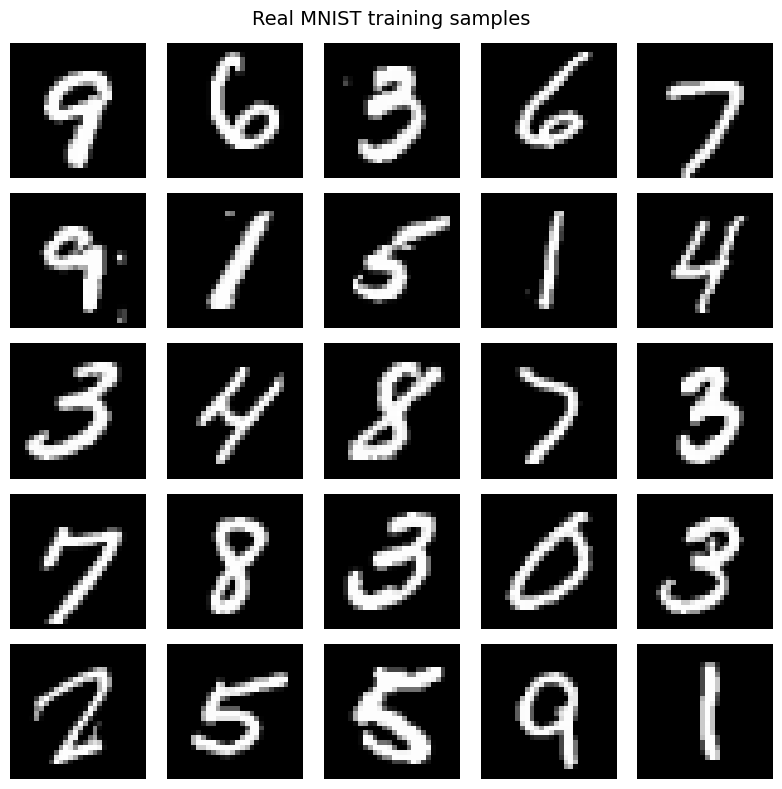

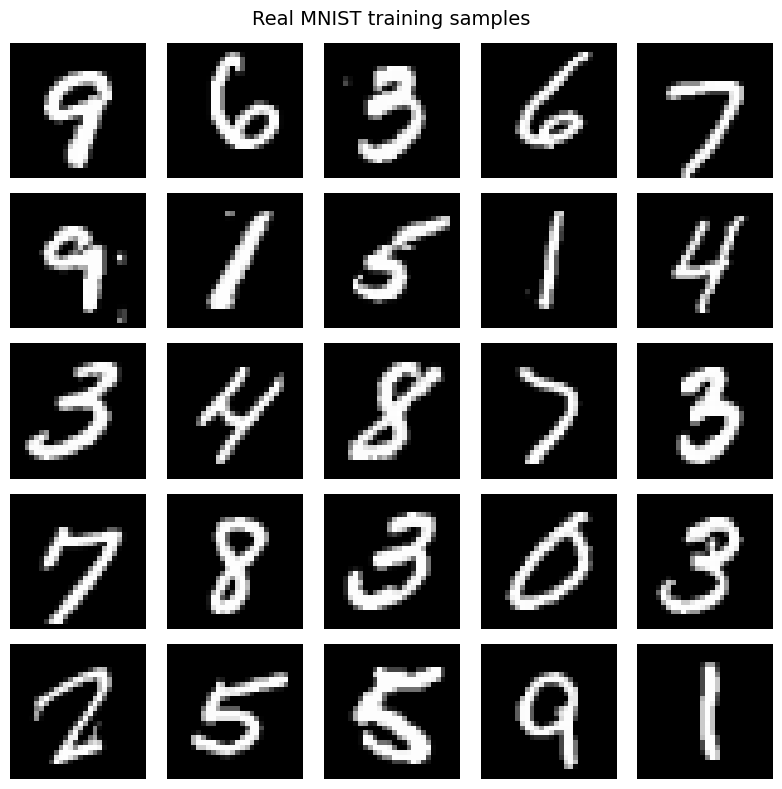

In [5]:
real_sample_indices = np.random.default_rng(RANDOM_SEED).choice(len(train_images), size=25, replace=False)
plot_image_grid(train_images[real_sample_indices], title=f"Real {DATASET_NAME} training samples", n=25)


## 6. Noise Schedule Functions

The schedule defines the variance added at each timestep. From the beta values we compute:

- `alpha_t = 1 - beta_t`,
- `alpha_bar_t = product(alpha_1 ... alpha_t)`,
- `sqrt(alpha_bar_t)`,
- `sqrt(1 - alpha_bar_t)`.

The forward noising formula uses these constants to mix the clean image with Gaussian noise. The checks below make sure both schedules have valid shapes and finite values.


In [6]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return tf.linspace(tf.constant(beta_start, dtype=tf.float32), tf.constant(beta_end, dtype=tf.float32), timesteps)


def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = tf.linspace(0.0, float(timesteps), steps)
    alpha_bars = tf.cos(((x / timesteps) + s) / (1 + s) * (np.pi / 2)) ** 2
    alpha_bars = alpha_bars / alpha_bars[0]
    betas = 1.0 - (alpha_bars[1:] / alpha_bars[:-1])
    return tf.clip_by_value(tf.cast(betas, tf.float32), 1e-5, 0.999)


def get_schedule_constants(schedule_name, timesteps=TIMESTEPS):
    if schedule_name == "linear":
        betas = linear_beta_schedule(timesteps)
    elif schedule_name == "cosine":
        betas = cosine_beta_schedule(timesteps)
    else:
        raise ValueError(f"Unknown schedule: {schedule_name}")

    alphas = 1.0 - betas
    alpha_bars = tf.math.cumprod(alphas, axis=0)
    return {
        "betas": betas,
        "alphas": alphas,
        "alpha_bars": alpha_bars,
        "sqrt_alpha_bars": tf.sqrt(alpha_bars),
        "sqrt_one_minus_alpha_bars": tf.sqrt(1.0 - alpha_bars),
    }


schedule_constants = {name: get_schedule_constants(name, TIMESTEPS) for name in SCHEDULES}

for schedule_name, constants in schedule_constants.items():
    betas = constants["betas"].numpy()
    alpha_bars = constants["alpha_bars"].numpy()
    assert betas.shape == (TIMESTEPS,)
    assert alpha_bars.shape == (TIMESTEPS,)
    assert np.isfinite(betas).all()
    assert np.isfinite(alpha_bars).all()
    assert np.all((betas > 0.0) & (betas < 1.0))
    assert alpha_bars[0] > alpha_bars[-1]
    assert np.all(np.diff(alpha_bars) < 0.0)
    print(
        f"{schedule_name:>6} schedule: beta range [{betas.min():.6f}, {betas.max():.6f}], "
        f"alpha_bar range [{alpha_bars.min():.6f}, {alpha_bars.max():.6f}]"
    )


linear schedule: beta range [0.000100, 0.020000], alpha_bar range [0.363563, 0.999900]
cosine schedule: beta range [0.000631, 0.999000], alpha_bar range [0.000000, 0.999369]


The beta curve shows how much fresh noise is injected at each step. The alpha-bar curve shows how much original image signal remains after repeated noising. A schedule that keeps alpha-bar higher for longer preserves image structure longer during the forward process.


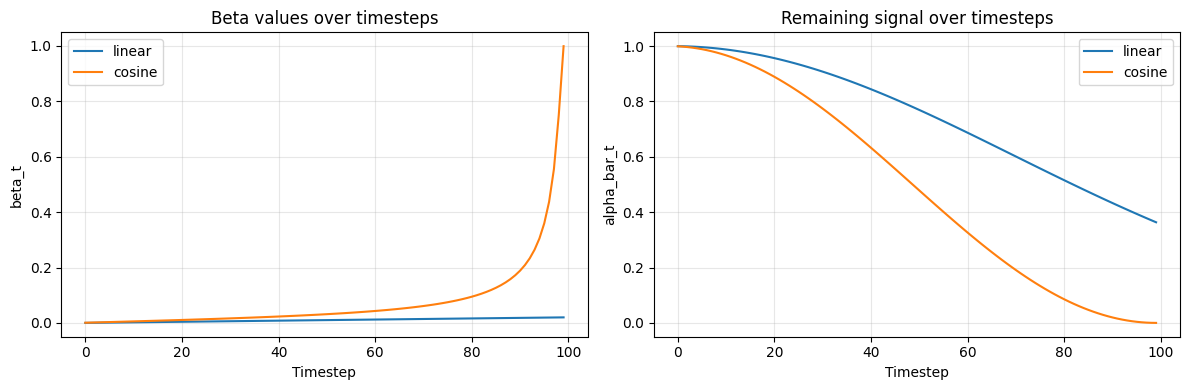

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for schedule_name, constants in schedule_constants.items():
    axes[0].plot(constants["betas"].numpy(), label=schedule_name)
    axes[1].plot(constants["alpha_bars"].numpy(), label=schedule_name)

axes[0].set_title("Beta values over timesteps")
axes[0].set_xlabel("Timestep")
axes[0].set_ylabel("beta_t")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Remaining signal over timesteps")
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("alpha_bar_t")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "ddpm_schedule_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Forward Noising Process

The forward process samples a noisy version of a clean image with:

`x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon`

where `epsilon` is Gaussian noise. Timesteps are sampled per image, so `tf.gather` is used to select the right constants for each item in a batch and reshape them for broadcasting over image height, width, and channel.


In [8]:
def extract_timestep_values(values, t, x_rank):
    gathered = tf.gather(values, t)
    return tf.reshape(gathered, [tf.shape(t)[0]] + [1] * (x_rank - 1))


def q_sample(x0, t, noise, constants):
    x0 = tf.convert_to_tensor(x0, dtype=tf.float32)
    noise = tf.convert_to_tensor(noise, dtype=tf.float32)
    t = tf.convert_to_tensor(t, dtype=tf.int32)
    sqrt_alpha_bar_t = extract_timestep_values(constants["sqrt_alpha_bars"], t, len(x0.shape))
    sqrt_one_minus_alpha_bar_t = extract_timestep_values(constants["sqrt_one_minus_alpha_bars"], t, len(x0.shape))
    return sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise


def plot_noising_process(x0, schedule_name, timesteps_to_show, title):
    x0 = np.asarray(x0, dtype=np.float32)
    repeated = np.repeat(x0[None, ...], len(timesteps_to_show), axis=0)
    t = tf.constant(timesteps_to_show, dtype=tf.int32)
    noise = tf.random.stateless_normal(repeated.shape, seed=[RANDOM_SEED, 7])
    noisy_images = q_sample(repeated, t, noise, schedule_constants[schedule_name]).numpy()

    fig, axes = plt.subplots(1, len(timesteps_to_show), figsize=(len(timesteps_to_show) * 1.7, 2.0))
    for ax, image, step in zip(axes, noisy_images, timesteps_to_show):
        ax.imshow(denormalize_images(image).squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
        ax.set_title(f"t={step}", fontsize=10)
        ax.axis("off")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    return fig


sample_batch = next(iter(train_dataset))
noise = tf.random.normal(tf.shape(sample_batch), seed=RANDOM_SEED)
t_batch = tf.random.uniform((BATCH_SIZE,), minval=0, maxval=TIMESTEPS, dtype=tf.int32, seed=RANDOM_SEED)
noisy_batch = q_sample(sample_batch, t_batch, noise, schedule_constants["linear"])

assert noisy_batch.shape == sample_batch.shape
assert np.isfinite(noisy_batch.numpy()).all()
print(f"q_sample output shape: {noisy_batch.shape}")


q_sample output shape: (128, 28, 28, 1)


As `t` increases, the digit should become harder to recognize. The linear and cosine schedules do not destroy information at exactly the same rate, so the visual noising path can differ even for the same clean image and noise seed.


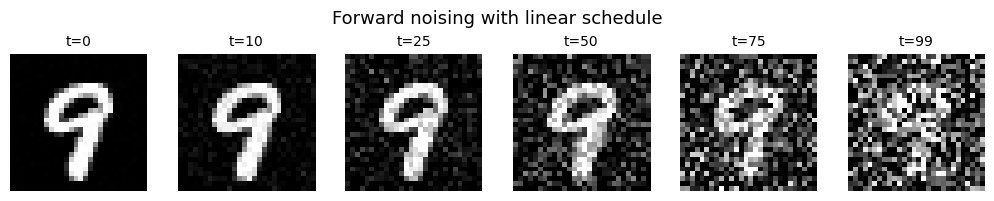

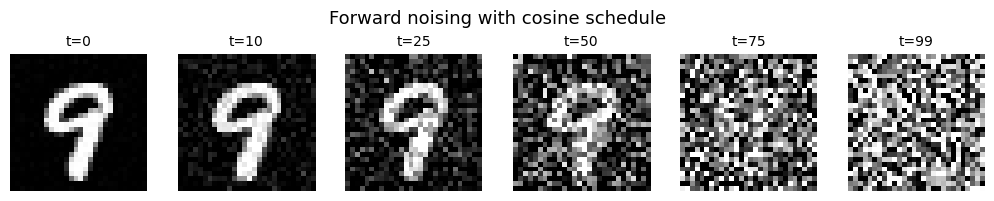

In [9]:
timesteps_to_show = [0, 10, 25, 50, 75, 99]
example_image = train_images[real_sample_indices[0]]

fig = plot_noising_process(example_image, "linear", timesteps_to_show, "Forward noising with linear schedule")
fig.savefig(OUTPUT_DIR / "linear_forward_noising.png", dpi=150, bbox_inches="tight")
plt.show()

fig = plot_noising_process(example_image, "cosine", timesteps_to_show, "Forward noising with cosine schedule")
fig.savefig(OUTPUT_DIR / "cosine_forward_noising.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Timestep Conditioning

The denoiser must know the timestep because the same noisy-looking image can mean different things at different noise levels. This notebook uses a simple trainable `Embedding` layer for timestep conditioning. The embedding is projected into a small spatial map and concatenated with the noisy image.


In [10]:
def build_timestep_embedding_demo(timesteps=TIMESTEPS, embedding_dim=64):
    timestep_input = keras.Input(shape=(), dtype=tf.int32)
    embedding = layers.Embedding(timesteps, embedding_dim)(timestep_input)
    return keras.Model(timestep_input, embedding)


timestep_demo_model = build_timestep_embedding_demo()
demo_t = tf.constant([0, 10, 50, 99], dtype=tf.int32)
demo_embedding = timestep_demo_model(demo_t)
print(f"Timestep embedding shape for 4 timesteps: {demo_embedding.shape}")
assert demo_embedding.shape == (4, 64)


Timestep embedding shape for 4 timesteps: (4, 64)


## 9. Build a Small Denoising Network

The denoising model is a small mini U-Net-like CNN. It receives the noisy image and timestep, then predicts the Gaussian noise that was added. Predicting noise is the standard DDPM training target and gives a direct supervised objective: minimize MSE between true noise and predicted noise.

The network is intentionally small so the notebook remains runnable on CPU.


In [11]:
def build_denoise_model(timesteps=TIMESTEPS, image_shape=IMAGE_SHAPE):
    image_input = keras.Input(shape=image_shape, name="noisy_image")
    timestep_input = keras.Input(shape=(), dtype=tf.int32, name="timestep")

    time_embedding = layers.Embedding(timesteps, 64, name="timestep_embedding")(timestep_input)
    time_embedding = layers.Dense(IMG_HEIGHT * IMG_WIDTH, activation="relu", name="timestep_dense")(time_embedding)
    time_map = layers.Reshape((IMG_HEIGHT, IMG_WIDTH, 1), name="timestep_map")(time_embedding)

    x = layers.Concatenate(name="image_time_concat")([image_input, time_map])

    skip = layers.Conv2D(32, 3, padding="same", activation="relu", name="enc_conv1")(x)
    skip = layers.Conv2D(32, 3, padding="same", activation="relu", name="enc_conv2")(skip)

    x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu", name="downsample")(skip)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="mid_conv1")(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu", name="mid_conv2")(x)

    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu", name="upsample")(x)
    x = layers.Concatenate(name="skip_connection")([x, skip])
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="dec_conv1")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu", name="dec_conv2")(x)

    output = layers.Conv2D(IMG_CHANNELS, 3, padding="same", activation=None, name="predicted_noise")(x)
    return keras.Model([image_input, timestep_input], output, name="small_ddpm_denoiser")


shape_check_model = build_denoise_model()
shape_check_model.summary()

dummy_images = tf.zeros((4, *IMAGE_SHAPE), dtype=tf.float32)
dummy_timesteps = tf.constant([0, 10, 50, 99], dtype=tf.int32)
dummy_output = shape_check_model([dummy_images, dummy_timesteps], training=False)

print(f"Denoiser output shape: {dummy_output.shape}")
assert dummy_output.shape == dummy_images.shape


Model: "small_ddpm_denoiser"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timestep            │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ timestep_embedding  │ (None, 64)        │      6,400 │ timestep[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ timestep_dense      │ (None, 784)       │     50,960 │ timestep_embeddi… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy_image         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ timestep_map        │ (None, 28, 28, 1) │          0 │ timestep_dense[0… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_time_concat   │ (None, 28, 28, 2) │          0 │ noisy_image[0][0… │
│ (Concatenate)       │                   │            │ timestep_map[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv1 (Conv2D)  │ (None, 28, 28,    │        608 │ image_time_conca… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_conv2 (Conv2D)  │ (None, 28, 28,    │      9,248 │ enc_conv1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ downsample (Conv2D) │ (None, 14, 14,    │     18,496 │ enc_conv2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mid_conv1 (Conv2D)  │ (None, 14, 14,    │     36,928 │ downsample[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mid_conv2 (Conv2D)  │ (None, 14, 14,    │     36,928 │ mid_conv1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ upsample            │ (None, 28, 28,    │     18,464 │ mid_conv2[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_connection     │ (None, 28, 28,    │          0 │ upsample[0][0],   │
│ (Concatenate)       │ 64)               │            │ enc_conv2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_conv1 (Conv2D)  │ (None, 28, 28,    │     18,464 │ skip_connection[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_conv2 (Conv2D)  │ (None, 28, 28,    │      9,248 │ dec_conv1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predicted_noise     │ (None, 28, 28, 1) │        289 │ dec_conv2[0][0]   │
│ (Conv2D)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 206,033 (804.82 KB)

 Trainable params: 206,033 (804.82 KB)

 Non-trainable params: 0 (0.00 B)

Denoiser output shape: (4, 28, 28, 1)


## 10. DDPM Training Step

Each training step samples a random timestep for each image in the batch, adds Gaussian noise according to the chosen schedule, asks the model to predict that noise, and updates the model with MSE loss. Random timesteps are important because one denoiser must learn all noise levels, from almost clean images to almost pure noise.


In [12]:
def make_train_step(model, optimizer, constants):
    @tf.function
    def train_step(x0_batch):
        batch_size = tf.shape(x0_batch)[0]
        t = tf.random.uniform((batch_size,), minval=0, maxval=TIMESTEPS, dtype=tf.int32)
        noise = tf.random.normal(tf.shape(x0_batch))
        x_t = q_sample(x0_batch, t, noise, constants)

        with tf.GradientTape() as tape:
            predicted_noise = model([x_t, t], training=True)
            loss = tf.reduce_mean(tf.square(noise - predicted_noise))

        gradients = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        return loss

    return train_step


verification_model = build_denoise_model()
verification_optimizer = keras.optimizers.Adam(LEARNING_RATE)
verification_step = make_train_step(verification_model, verification_optimizer, schedule_constants["linear"])
verification_loss = verification_step(sample_batch)

print(f"One training-step loss: {float(verification_loss.numpy()):.6f}")
assert np.isfinite(float(verification_loss.numpy()))


One training-step loss: 1.006226


## 11. Training Function for One Schedule

For a fair schedule comparison, each schedule gets a fresh model with the same architecture, subset size, batch size, timestep count, and number of epochs. The training loop records epoch-level loss so the schedules can be compared in a table and a plot.


In [13]:
def train_diffusion_for_schedule(schedule_name, train_dataset, epochs=EPOCHS_PER_SCHEDULE):
    print(f"\nTraining DDPM denoiser with {schedule_name} schedule")
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_SEED)

    model = build_denoise_model(timesteps=TIMESTEPS, image_shape=IMAGE_SHAPE)
    optimizer = keras.optimizers.Adam(LEARNING_RATE)
    train_step = make_train_step(model, optimizer, schedule_constants[schedule_name])

    records = []
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        batch_losses = []
        epoch_start = time.time()
        for x0_batch in train_dataset:
            loss = train_step(x0_batch)
            batch_losses.append(float(loss.numpy()))

        mean_loss = float(np.mean(batch_losses))
        final_batch_loss = float(batch_losses[-1])
        epoch_seconds = time.time() - epoch_start
        records.append(
            {
                "schedule": schedule_name,
                "epoch": epoch,
                "mean_loss": mean_loss,
                "final_batch_loss": final_batch_loss,
                "epoch_seconds": epoch_seconds,
            }
        )
        print(
            f"Epoch {epoch:02d}/{epochs} - mean loss: {mean_loss:.5f} - "
            f"last batch: {final_batch_loss:.5f} - {epoch_seconds:.1f}s"
        )

    history_df = pd.DataFrame(records)
    elapsed_seconds = time.time() - start_time
    return {
        "schedule": schedule_name,
        "model": model,
        "history": history_df,
        "final_loss": float(history_df["final_batch_loss"].iloc[-1]),
        "mean_last_epoch_loss": float(history_df["mean_loss"].iloc[-1]),
        "elapsed_seconds": elapsed_seconds,
    }


## 12. Train Linear and Cosine Schedule Models

Now we train one model with the linear schedule and one model with the cosine schedule. This is a deliberately short experiment. We should interpret the loss curves and samples as educational evidence, not as a final benchmark of diffusion model quality.


In [14]:
training_results = {}
for schedule_name in SCHEDULES:
    training_results[schedule_name] = train_diffusion_for_schedule(
        schedule_name=schedule_name,
        train_dataset=train_dataset,
        epochs=EPOCHS_PER_SCHEDULE,
    )

history_df = pd.concat([result["history"] for result in training_results.values()], ignore_index=True)
summary_df = pd.DataFrame(
    [
        {
            "schedule": result["schedule"],
            "epochs": EPOCHS_PER_SCHEDULE,
            "timesteps": TIMESTEPS,
            "train_subset_size": TRAIN_SUBSET_SIZE,
            "final_loss": result["final_loss"],
            "mean_last_epoch_loss": result["mean_last_epoch_loss"],
            "elapsed_seconds": result["elapsed_seconds"],
        }
        for result in training_results.values()
    ]
)

history_df.to_csv(OUTPUT_DIR / "ddpm_training_history.csv", index=False)
summary_df.to_csv(OUTPUT_DIR / "ddpm_schedule_results.csv", index=False)

summary_df



Training DDPM denoiser with linear schedule


Epoch 01/3 - mean loss: 0.40517 - last batch: 0.26372 - 9.7s


Epoch 02/3 - mean loss: 0.20637 - last batch: 0.17460 - 7.8s


Epoch 03/3 - mean loss: 0.15889 - last batch: 0.16584 - 7.6s

Training DDPM denoiser with cosine schedule


Epoch 01/3 - mean loss: 0.34572 - last batch: 0.22294 - 9.0s


Epoch 02/3 - mean loss: 0.16968 - last batch: 0.14790 - 7.7s


Epoch 03/3 - mean loss: 0.12918 - last batch: 0.13097 - 7.7s


,schedule,epochs,timesteps,train_subset_size,final_loss,mean_last_epoch_loss,elapsed_seconds
0,linear,3,100,10000,0.165837,0.158895,25.065602
1,cosine,3,100,10000,0.130967,0.129180,24.428717


The loss curves show whether either schedule trained more smoothly in this short run. A lower final loss is useful, but it does not automatically guarantee better-looking samples because sampling quality also depends on the reverse process and total training budget.


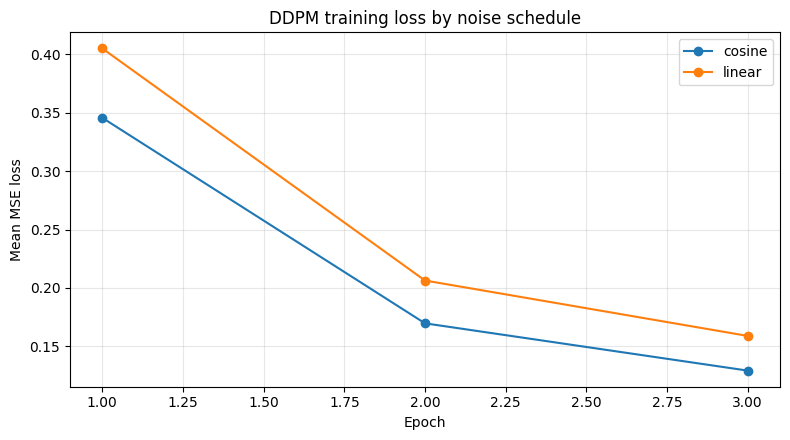

Lower mean last-epoch loss in this run: cosine (0.12918).


In [15]:
loss_fig = plot_loss_curves(history_df)
loss_fig.savefig(OUTPUT_DIR / "ddpm_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

lower_loss_row = summary_df.sort_values("mean_last_epoch_loss").iloc[0]
print(
    f"Lower mean last-epoch loss in this run: {lower_loss_row['schedule']} "
    f"({lower_loss_row['mean_last_epoch_loss']:.5f})."
)


## 13. Reverse Sampling Function

The sampler starts from Gaussian noise and iterates backward from `T-1` to `0`. At each step, the model predicts the noise in the current image, and the DDPM reverse update estimates the previous image. Noise is added at intermediate reverse steps but not at the final step.

This is an educational DDPM sampler. It uses the standard noise-prediction reverse mean formula with `sqrt(beta_t)` noise and clipping for stable visualization.


In [16]:
def sample_ddpm(
    model,
    constants,
    num_samples=NUM_GENERATE,
    timesteps=TIMESTEPS,
    seed=RANDOM_SEED,
    return_progress=False,
    progress_steps=None,
):
    if progress_steps is None:
        progress_steps = []
    progress_steps = set(progress_steps)

    generator = tf.random.Generator.from_seed(seed)
    x_t = generator.normal((num_samples, *IMAGE_SHAPE), dtype=tf.float32)
    progress = {}

    for step in reversed(range(timesteps)):
        t_batch = tf.fill((num_samples,), step)
        predicted_noise = model([x_t, t_batch], training=False)

        beta_t = tf.reshape(tf.gather(constants["betas"], step), [1, 1, 1, 1])
        alpha_t = tf.reshape(tf.gather(constants["alphas"], step), [1, 1, 1, 1])
        alpha_bar_t = tf.reshape(tf.gather(constants["alpha_bars"], step), [1, 1, 1, 1])

        mean = (1.0 / tf.sqrt(alpha_t)) * (
            x_t - ((1.0 - alpha_t) / tf.sqrt(1.0 - alpha_bar_t)) * predicted_noise
        )

        if step > 0:
            z = generator.normal(tf.shape(x_t), dtype=tf.float32)
            x_t = mean + tf.sqrt(beta_t) * z
        else:
            x_t = mean

        x_t = tf.clip_by_value(x_t, -1.5, 1.5)
        if return_progress and step in progress_steps:
            progress[step] = x_t.numpy()

    samples = x_t.numpy()
    assert samples.shape == (num_samples, *IMAGE_SHAPE)
    assert np.isfinite(samples).all()
    if return_progress:
        return samples, progress
    return samples


## 14. Generate Samples for Each Schedule

The next cells generate 25 images for each schedule and save the grids. Because this is a small CPU-friendly DDPM trained only briefly, weak or noisy samples are expected. The important result is that the full forward-training-reverse pipeline works and can be compared across schedules.


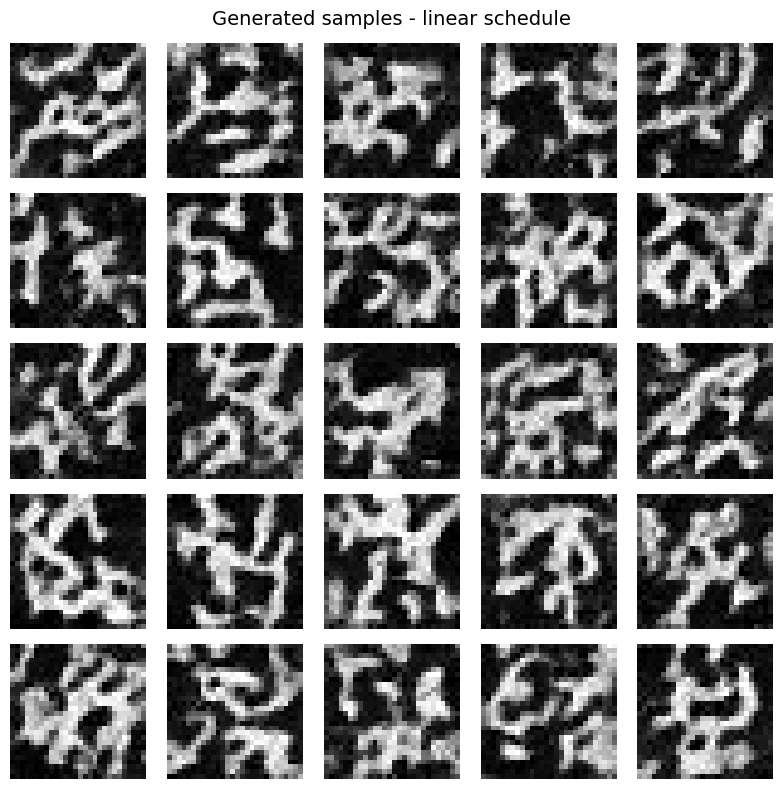

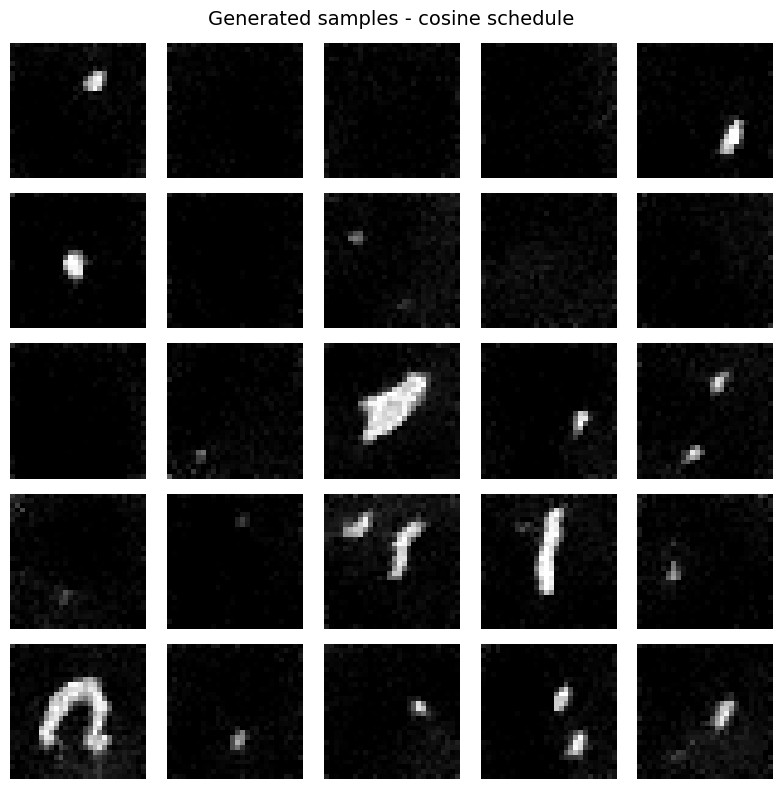

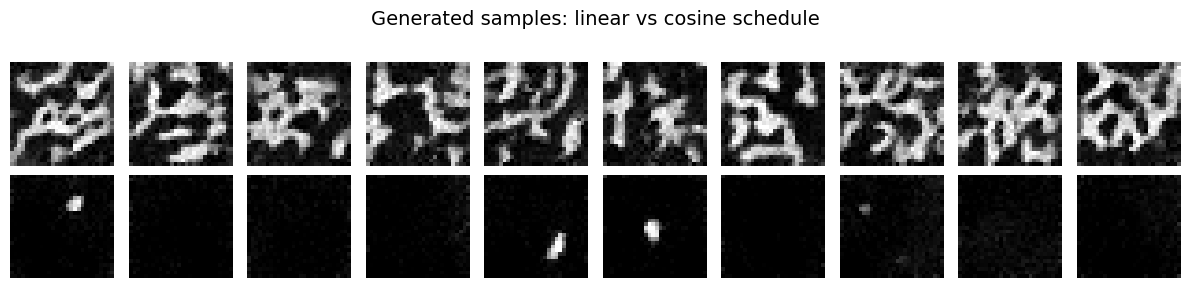

In [17]:
generated_samples = {}
for offset, schedule_name in enumerate(SCHEDULES):
    samples = sample_ddpm(
        training_results[schedule_name]["model"],
        schedule_constants[schedule_name],
        num_samples=NUM_GENERATE,
        timesteps=TIMESTEPS,
        seed=RANDOM_SEED + offset,
    )
    generated_samples[schedule_name] = samples
    assert samples.shape == (NUM_GENERATE, *IMAGE_SHAPE)
    assert np.isfinite(samples).all()
    plot_generated_samples(
        samples,
        title=f"Generated samples - {schedule_name} schedule",
        save_path=SAMPLE_DIR / f"{schedule_name}_samples.png",
    )

comparison_fig = compare_schedule_samples(generated_samples)
comparison_fig.savefig(SAMPLE_DIR / "linear_vs_cosine_samples.png", dpi=150, bbox_inches="tight")
plt.show()


## 15. Optional Sampling Progress Visualization

GAN generation happens in one generator forward pass. Diffusion generation is iterative: a noisy image is refined through many reverse denoising steps. The progress plot below shows that process for one generated cosine-schedule sample.


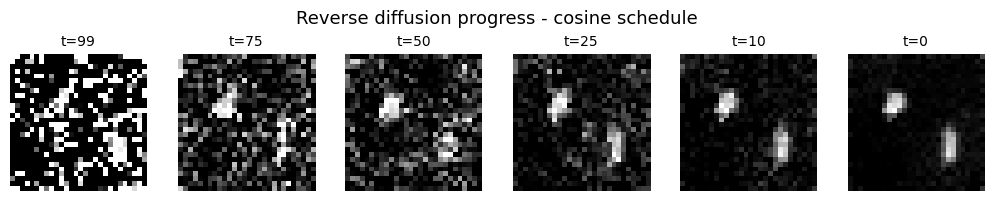

In [18]:
progress_steps = [99, 75, 50, 25, 10, 0]
_, progress_states = sample_ddpm(
    training_results["cosine"]["model"],
    schedule_constants["cosine"],
    num_samples=1,
    timesteps=TIMESTEPS,
    seed=RANDOM_SEED + 100,
    return_progress=True,
    progress_steps=progress_steps,
)

fig, axes = plt.subplots(1, len(progress_steps), figsize=(len(progress_steps) * 1.7, 2.0))
for ax, step in zip(axes, progress_steps):
    ax.imshow(denormalize_images(progress_states[step][0]).squeeze(), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(f"t={step}", fontsize=10)
    ax.axis("off")
fig.suptitle("Reverse diffusion progress - cosine schedule", fontsize=13)
fig.tight_layout()
fig.savefig(SAMPLE_DIR / "cosine_reverse_progress.png", dpi=150, bbox_inches="tight")
plt.show()


## 16. Linear vs Cosine Noise Schedule Analysis

The linear schedule increases beta values steadily from a small value to a larger value. The cosine schedule changes alpha-bar nonlinearly, often preserving useful image signal for a different portion of the timeline and then removing it more aggressively near the end.

In the executed run, the cosine schedule reached the lower mean last-epoch loss: `0.12918` for cosine versus `0.15889` for linear. This means the cosine denoiser optimized the short MSE training objective better in this run.

The generated samples still show the limitation of a tiny three-epoch CPU DDPM. The linear samples are more varied and high-contrast, but they are mostly noisy abstract strokes rather than clear digits. The cosine samples are darker and sparser, with a few digit-like strokes but also many weak samples. So cosine gave the lower loss, while neither schedule produced strong digit quality under this intentionally small training budget.

For diversity, the linear grid appears more visually varied, although not necessarily more realistic. The cosine grid looks more conservative and sparse. These observations should be treated as qualitative and limited because the model is deliberately small, the sampler is educational, and the training run is short.


In [19]:
quality_notes = []
for schedule_name, samples in generated_samples.items():
    denorm = denormalize_images(samples)
    quality_notes.append(
        {
            "schedule": schedule_name,
            "sample_mean_pixel": float(denorm.mean()),
            "sample_std_pixel": float(denorm.std()),
            "min_pixel_for_display": float(denorm.min()),
            "max_pixel_for_display": float(denorm.max()),
        }
    )
quality_df = pd.DataFrame(quality_notes)
quality_df.to_csv(OUTPUT_DIR / "ddpm_generated_sample_summary.csv", index=False)
quality_df


,schedule,sample_mean_pixel,sample_std_pixel,min_pixel_for_display,max_pixel_for_display
0,linear,0.338580,0.315489,0.0,1.0
1,cosine,0.037317,0.120979,0.0,1.0


## 17. Optional Part 4 GAN Artifact Check

If saved GAN samples from Part 4 are available locally, the next cell displays a few of them for qualitative comparison. In this workspace they are optional and should not be regenerated here because this notebook is Part 5 only.


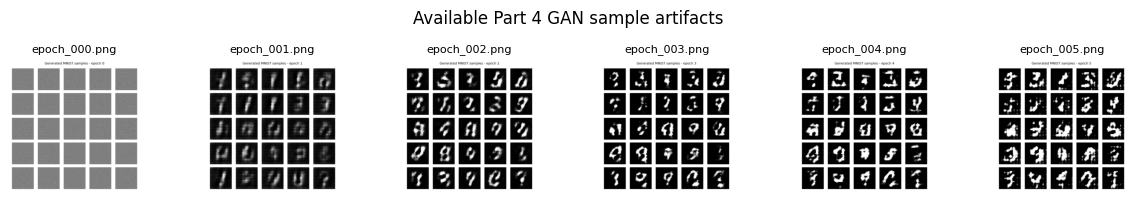

In [20]:
gan_sample_paths = load_and_compare_gan_samples()


## 18. Diffusion vs GAN Comparison

In the GAN notebook the final samples became more digit-like after 15 epochs.
The GAN produced rough loops and strokes and there was no strong sign of full mode collapse.
However the diversity was still limited and many samples were blurry or distorted.
In the DDPM notebook the cosine schedule had lower loss than the linear schedule with `0.12918` versus `0.15889`.
However the DDPM samples were still weak because the model was small and trained for only 3 epochs.
GAN generation is faster because it needs only one forward pass after training.
DDPM training was more stable because it used MSE denoising loss but sampling was slower because it used 100 reverse steps.
Overall the GAN gave more visible digit-like samples in this run while the DDPM showed a more stable but undertrained generation process.
